# Sesión 4. Modelos base: entrenamiento, testing y métricas
---

## Setup y carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Paleta de coores
VIOLET = '#6C4FF6'
CORAL  = '#FF6B6B'
AMBER  = '#FFB020'
DARK   = '#1B1035'
MUTED  = '#6B6478'
GREEN  = '#2ECC71'

# ── Datasets ──
hp      = pd.read_csv('../data/train.csv')
titanic = pd.read_csv('../data/titanic/train.csv')

print('🏠 House Prices:', hp.shape)
print('🚢 Titanic:     ', titanic.shape)

display(hp.head(3))
display(titanic.head(3))

🏠 House Prices: (1460, 81)
🚢 Titanic:      (891, 12)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


---
## Modelos baseline

Un **baseline** es el modelo más simple posible. Establece el **piso mínimo de rendimiento aceptable**.

> Si tu modelo sofisticado no supera al baseline, algo está mal en tu **pipeline**, no en tu elección de modelo.

| Tarea | Baseline típico |
|-------|-----------------|
| Regresión | Predecir siempre la media del target |
| Clasificación | Predecir siempre la clase mayoritaria |

In [2]:
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

# Baseline regresión
X_hp = hp[['GrLivArea','OverallQual','YearBuilt','TotalBsmtSF','GarageCars']]
y_hp = np.log1p(hp['SalePrice'])   # target transformado

X_hp_tr, X_hp_te, y_hp_tr, y_hp_te = train_test_split(
    X_hp, y_hp, test_size=0.2, random_state=42)

dummy_reg = DummyRegressor(strategy='mean')
dummy_reg.fit(X_hp_tr, y_hp_tr)
pred_dummy_reg = dummy_reg.predict(X_hp_te)

mae_base = mean_absolute_error(y_hp_te, pred_dummy_reg)
r2_base  = r2_score(y_hp_te, pred_dummy_reg)
print(f'Baseline regresión.  MAE: {mae_base:.4f}  |  R²: {r2_base:.4f}')

# Baseline clasificación
titanic_clean = titanic.dropna(subset=['Age'])
titanic_clean = titanic_clean.copy()
titanic_clean['Sex'] = (titanic_clean['Sex'] == 'female').astype(int)

X_tt = titanic_clean[['Pclass','Sex','Age','SibSp','Fare']]
y_tt = titanic_clean['Survived']

X_tt_tr, X_tt_te, y_tt_tr, y_tt_te = train_test_split(
    X_tt, y_tt, test_size=0.2, random_state=42, stratify=y_tt)

dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_tt_tr, y_tt_tr)
acc_base = accuracy_score(y_tt_te, dummy_clf.predict(X_tt_te))
print(f'Baseline clasificación. Accuracy: {acc_base:.4f}')

Baseline regresión.  MAE: 0.3371  |  R²: -0.0058
Baseline clasificación. Accuracy: 0.5944


---
## Regresión lineal

Encuentra el hiperplano que minimiza el MSE entre predicciones y valores reales:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Cada coeficiente $\beta_i$ indica cuánto cambia el target por una unidad de cambio en esa feature, manteniendo todo lo demás constante.

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

pipe_lr.fit(X_hp_tr, y_hp_tr)
pred_lr = pipe_lr.predict(X_hp_te)

mae_lr  = mean_absolute_error(y_hp_te, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_hp_te, pred_lr))
r2_lr   = r2_score(y_hp_te, pred_lr)

print('=== Regresión Lineal ===')
print(f'MAE:  {mae_lr:.4f}  (baseline: {mae_base:.4f})  {'SUPERADO' if mae_lr < mae_base else 'NO SUPERADO'}')
print(f'RMSE: {rmse_lr:.4f}')
print(f'R²:   {r2_lr:.4f}  (baseline: {r2_base:.4f})')
print()

# Coeficientes — interpretabilidad
coefs = pd.Series(
    pipe_lr.named_steps['model'].coef_,
    index=X_hp.columns
).sort_values(key=abs, ascending=False)

print('Coeficientes (features escaladas):')
print(coefs.round(4).to_string())

=== Regresión Lineal ===
MAE:  0.1213  (baseline: 0.3371)  SUPERADO
RMSE: 0.1739
R²:   0.8380  (baseline: -0.0058)

Coeficientes (features escaladas):
OverallQual    0.1380
GrLivArea      0.1227
YearBuilt      0.0719
GarageCars     0.0712
TotalBsmtSF    0.0455


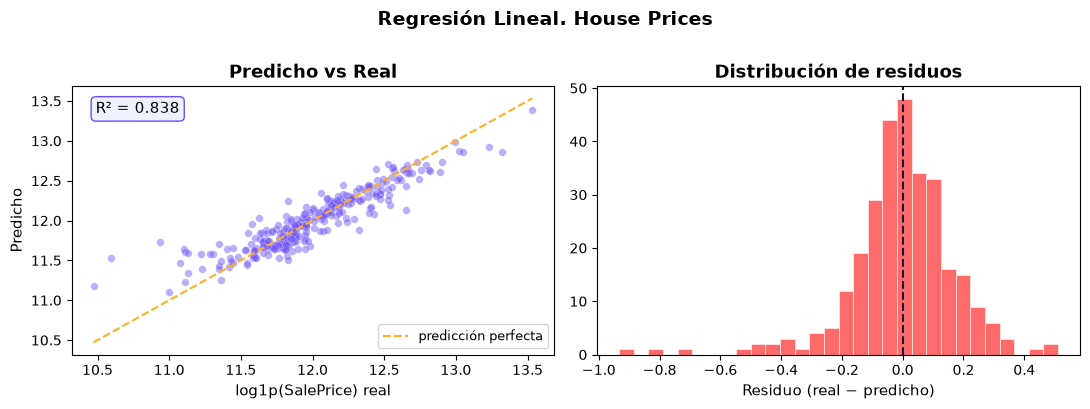

In [4]:
# Visualización: predicho vs real, distribución de residuos
residuos = y_hp_te.values - pred_lr

fig, axes = plt.subplots(1, 2, figsize=(11, 4), facecolor='white')

axes[0].scatter(y_hp_te, pred_lr, alpha=0.45, color=VIOLET, edgecolors='white',
                linewidth=0.3, s=30)
lims = [min(y_hp_te.min(), pred_lr.min()), max(y_hp_te.max(), pred_lr.max())]
axes[0].plot(lims, lims, '--', color=AMBER, linewidth=1.5, label='predicción perfecta')
axes[0].set_xlabel('log1p(SalePrice) real', fontsize=11)
axes[0].set_ylabel('Predicho', fontsize=11)
axes[0].set_title('Predicho vs Real', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].annotate(f'R² = {r2_lr:.3f}', xy=(0.05, 0.90),
                 xycoords='axes fraction', fontsize=11,
                 bbox=dict(boxstyle='round,pad=0.3', fc='#EEF2FF', ec=VIOLET))

axes[1].hist(residuos, bins=30, color=CORAL, edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color=DARK, linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residuo (real − predicho)', fontsize=11)
axes[1].set_title('Distribución de residuos', fontsize=13, fontweight='bold')

fig.suptitle('Regresión Lineal. House Prices', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Regresión logística

Aplica una regresión lineal y pasa el resultado por la función sigmoide $\sigma$ para convertirlo en probabilidad:

$$z = \beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n \quad \xrightarrow{\sigma} \quad P(y=1|x) = \frac{1}{1+e^{-z}}$$

La sigmoide nunca sale del rango [0, 1]; perfecta para modelar probabilidades.

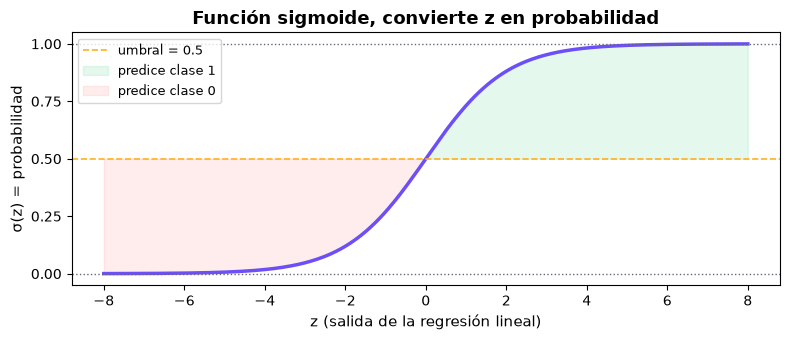

In [5]:
# Visualizar la función sigmoide
z = np.linspace(-8, 8, 300)
sigma = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(8, 3.5), facecolor='white')
ax.plot(z, sigma, color=VIOLET, linewidth=2.5)
ax.axhline(0.5, color=AMBER, linestyle='--', linewidth=1.2, label='umbral = 0.5')
ax.axhline(1.0, color=MUTED, linestyle=':', linewidth=1.0)
ax.axhline(0.0, color=MUTED, linestyle=':', linewidth=1.0)
ax.fill_between(z, sigma, 0.5, where=(sigma > 0.5), alpha=0.12, color=GREEN, label='predice clase 1')
ax.fill_between(z, sigma, 0.5, where=(sigma < 0.5), alpha=0.12, color=CORAL, label='predice clase 0')
ax.set_xlabel('z (salida de la regresión lineal)', fontsize=11)
ax.set_ylabel('σ(z) = probabilidad', fontsize=11)
ax.set_title('Función sigmoide, convierte z en probabilidad', fontsize=13, fontweight='bold')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

pipe_log = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(random_state=42, max_iter=1000))
])

pipe_log.fit(X_tt_tr, y_tt_tr)
pred_log      = pipe_log.predict(X_tt_te)
pred_log_prob = pipe_log.predict_proba(X_tt_te)[:, 1]

print('=== Regresión Logística: Titanic ===')
print(classification_report(y_tt_te, pred_log,
                             target_names=['No sobrevivió','Sobrevivió']))

print('Coeficientes (dirección del efecto):')
coefs_log = pd.Series(
    pipe_log.named_steps['model'].coef_[0],
    index=X_tt.columns
).sort_values(ascending=False)
print(coefs_log.round(3).to_string())

=== Regresión Logística: Titanic ===
               precision    recall  f1-score   support

No sobrevivió       0.83      0.82      0.83        85
   Sobrevivió       0.75      0.76      0.75        58

     accuracy                           0.80       143
    macro avg       0.79      0.79      0.79       143
 weighted avg       0.80      0.80      0.80       143

Coeficientes (dirección del efecto):
Sex       1.215
Fare      0.063
SibSp    -0.327
Age      -0.641
Pclass   -1.044


---
## Métricas de clasificación en detalle

### Matriz de confusión

```
                   Predicho +      Predicho −
Real positivo  →      TP               FN
Real negativo  →      FP               TN
```

| Métrica | Fórmula | Responde a |
|---------|---------|------------|
| Accuracy | $(TP+TN)/(TP+TN+FP+FN)$ | ¿Qué fracción acerté en total? |
| Precision | $TP/(TP+FP)$ | De los que predije positivos, ¿cuántos lo eran? |
| Recall | $TP/(TP+FN)$ | De los positivos reales, ¿cuántos encontré? |
| Specificity | $TN/(TN+FP)$ | De los negativos reales, ¿cuántos identifiqué? |
| F1 | $2 \cdot \frac{P \cdot R}{P+R}$ | Balance entre precision y recall |

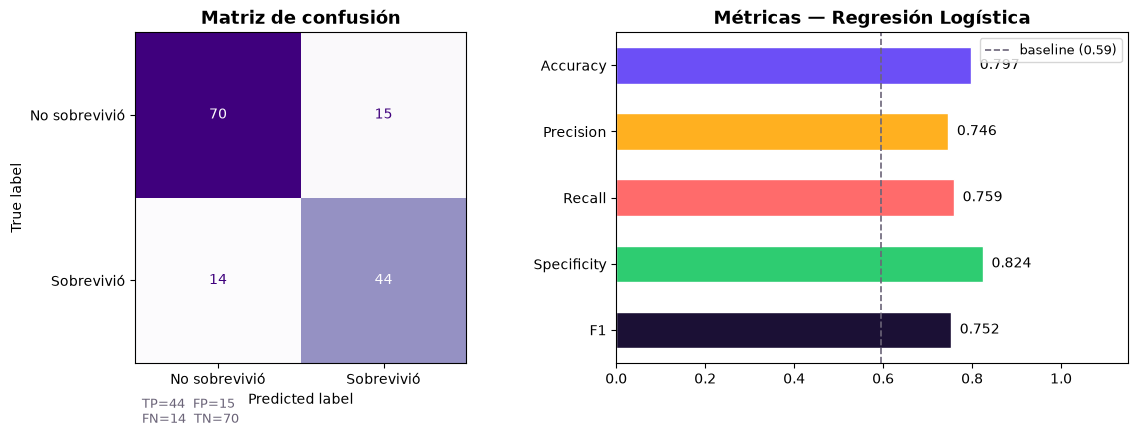

Accuracy:    0.797
Precision:   0.746
Recall:      0.759
Specificity: 0.824
F1-score:    0.752


In [7]:
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              precision_score, recall_score,
                              f1_score, accuracy_score)

cm = confusion_matrix(y_tt_te, pred_log)
tn, fp, fn, tp = cm.ravel()

accuracy    = (tp + tn) / (tp + tn + fp + fn)
precision   = tp / (tp + fp)
recall      = tp / (tp + fn)
specificity = tn / (tn + fp)
f1          = 2 * precision * recall / (precision + recall)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor='white')

# Matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No sobrevivió','Sobrevivió'])
disp.plot(ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title('Matriz de confusión', fontsize=13, fontweight='bold')
axes[0].annotate(f'TP={tp}  FP={fp}\nFN={fn}  TN={tn}',
                 xy=(0.02, -0.18), xycoords='axes fraction', fontsize=9, color=MUTED)

# Métricas como barras
metricas   = ['Accuracy','Precision','Recall','Specificity','F1']
valores    = [accuracy, precision, recall, specificity, f1]
colores    = [VIOLET, AMBER, CORAL, GREEN, DARK]

bars = axes[1].barh(metricas, valores, color=colores, edgecolor='white', height=0.55)
axes[1].set_xlim(0, 1.15)
axes[1].axvline(acc_base, color=MUTED, linestyle='--', linewidth=1.2,
                label=f'baseline ({acc_base:.2f})')
for bar, val in zip(bars, valores):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10)
axes[1].set_title('Métricas — Regresión Logística', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f'Accuracy:    {accuracy:.3f}')
print(f'Precision:   {precision:.3f}')
print(f'Recall:      {recall:.3f}')
print(f'Specificity: {specificity:.3f}')
print(f'F1-score:    {f1:.3f}')

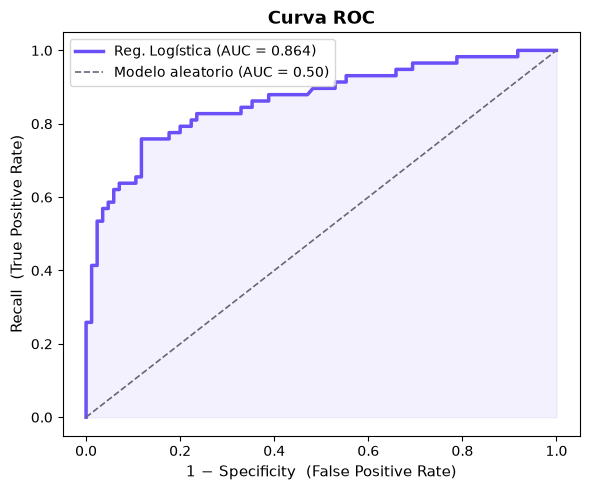

In [8]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_tt_te, pred_log_prob)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5), facecolor='white')
ax.plot(fpr, tpr, color=VIOLET, linewidth=2.5, label=f'Reg. Logística (AUC = {roc_auc:.3f})')
ax.plot([0,1],[0,1], color=MUTED, linestyle='--', linewidth=1.2, label='Modelo aleatorio (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.08, color=VIOLET)
ax.set_xlabel('1 − Specificity  (False Positive Rate)', fontsize=11)
ax.set_ylabel('Recall  (True Positive Rate)', fontsize=11)
ax.set_title('Curva ROC', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## KNN — K Nearest Neighbors

No aprende parámetros, memoriza los datos. Al predecir, busca los $K$ vecinos más cercanos usando distancia euclidiana:

$$d(p,q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}$$

- **Regresión:** promedia los valores de los $K$ vecinos
- **Clasificación:** vota por mayoría

### Bias-Varianza en KNN
| K pequeño (K=1) | K grande |
|-----------------|----------|
| Alta varianza, memoriza el ruido | Alto bias, predicciones demasiado suaves |
| Sobreajuste | Subajuste |

> **Regla práctica:** empieza con $K = \sqrt{n_{train}}$

In [9]:
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

k_inicial = int(np.sqrt(len(X_hp_tr)))
print(f'K inicial sugerido (√{len(X_hp_tr)}): {k_inicial}')

# KNN Regresión
pipe_knn_r = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  KNeighborsRegressor(n_neighbors=k_inicial))
])
pipe_knn_r.fit(X_hp_tr, y_hp_tr)
pred_knn_r = pipe_knn_r.predict(X_hp_te)

mae_knn_r  = mean_absolute_error(y_hp_te, pred_knn_r)
r2_knn_r   = r2_score(y_hp_te, pred_knn_r)

print(f'\nKNN Regresión (K={k_inicial}) MAE: {mae_knn_r:.4f}  |  R²: {r2_knn_r:.4f}')
print(f'Regresión Lineal                MAE: {mae_lr:.4f}  |  R²: {r2_lr:.4f}')

# KNN Clasificación
k_inicial_clf = int(np.sqrt(len(X_tt_tr)))
pipe_knn_c = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  KNeighborsClassifier(n_neighbors=k_inicial_clf))
])
pipe_knn_c.fit(X_tt_tr, y_tt_tr)
acc_knn_c = accuracy_score(y_tt_te, pipe_knn_c.predict(X_tt_te))
print(f'\nKNN Clasificación (K={k_inicial_clf})   Accuracy: {acc_knn_c:.4f}')
print(f'Reg. Logística               Accuracy: {accuracy:.4f}')

K inicial sugerido (√1168): 34

KNN Regresión (K=34) MAE: 0.1245  |  R²: 0.8134
Regresión Lineal                MAE: 0.1213  |  R²: 0.8380

KNN Clasificación (K=23)   Accuracy: 0.8322
Reg. Logística               Accuracy: 0.7972


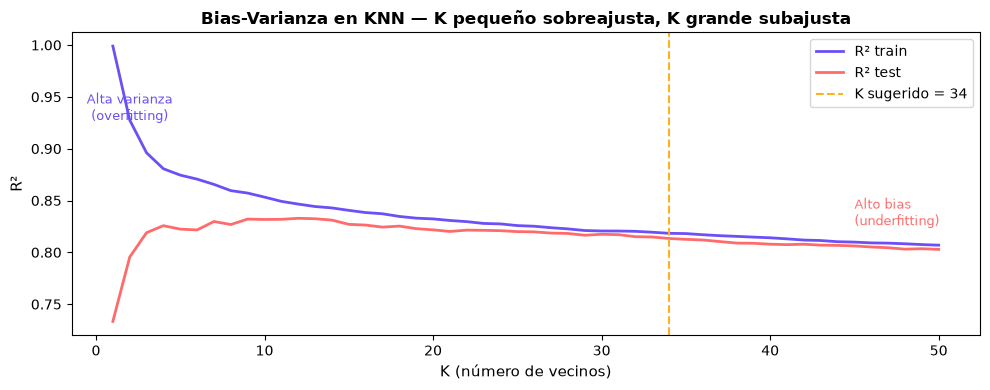

In [10]:
# Efecto de K en R²
ks       = range(1, 51)
r2_train = []
r2_test  = []

for k in ks:
    p = Pipeline([('s', StandardScaler()),
                  ('m', KNeighborsRegressor(n_neighbors=k))])
    p.fit(X_hp_tr, y_hp_tr)
    r2_train.append(r2_score(y_hp_tr, p.predict(X_hp_tr)))
    r2_test.append(r2_score(y_hp_te, p.predict(X_hp_te)))

fig, ax = plt.subplots(figsize=(10, 4), facecolor='white')
ax.plot(ks, r2_train, color=VIOLET, linewidth=2, label='R² train')
ax.plot(ks, r2_test,  color=CORAL,  linewidth=2, label='R² test')
ax.axvline(k_inicial, color=AMBER, linestyle='--', linewidth=1.5,
           label=f'K sugerido = {k_inicial}')
ax.set_xlabel('K (número de vecinos)', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('Bias-Varianza en KNN — K pequeño sobreajusta, K grande subajusta',
             fontsize=12, fontweight='bold')
ax.annotate('Alta varianza\n(overfitting)', xy=(2, r2_train[1]),
             fontsize=9, color=VIOLET, ha='center')
ax.annotate('Alto bias\n(underfitting)', xy=(45, r2_test[44]+0.02),
             fontsize=9, color=CORAL)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Decision Tree

Divide el espacio de features con preguntas binarias sucesivas. En cada nodo busca el split que maximiza la pureza de los subconjuntos:

$$Gini = 1 - \sum_k p_k^2 \qquad H = -\sum_k p_k \log_2(p_k)$$

Un nodo puro (solo una clase) tiene $Gini = 0$ y $H = 0$.

> ⚠️ Sin `max_depth`, el árbol crece hasta memorizar cada punto de train.

Decision Tree Regresión (max_depth=4)  MAE: 0.1569  |  R²: 0.7549
Decision Tree Clasificación (max_depth=4)  Accuracy: 0.8042


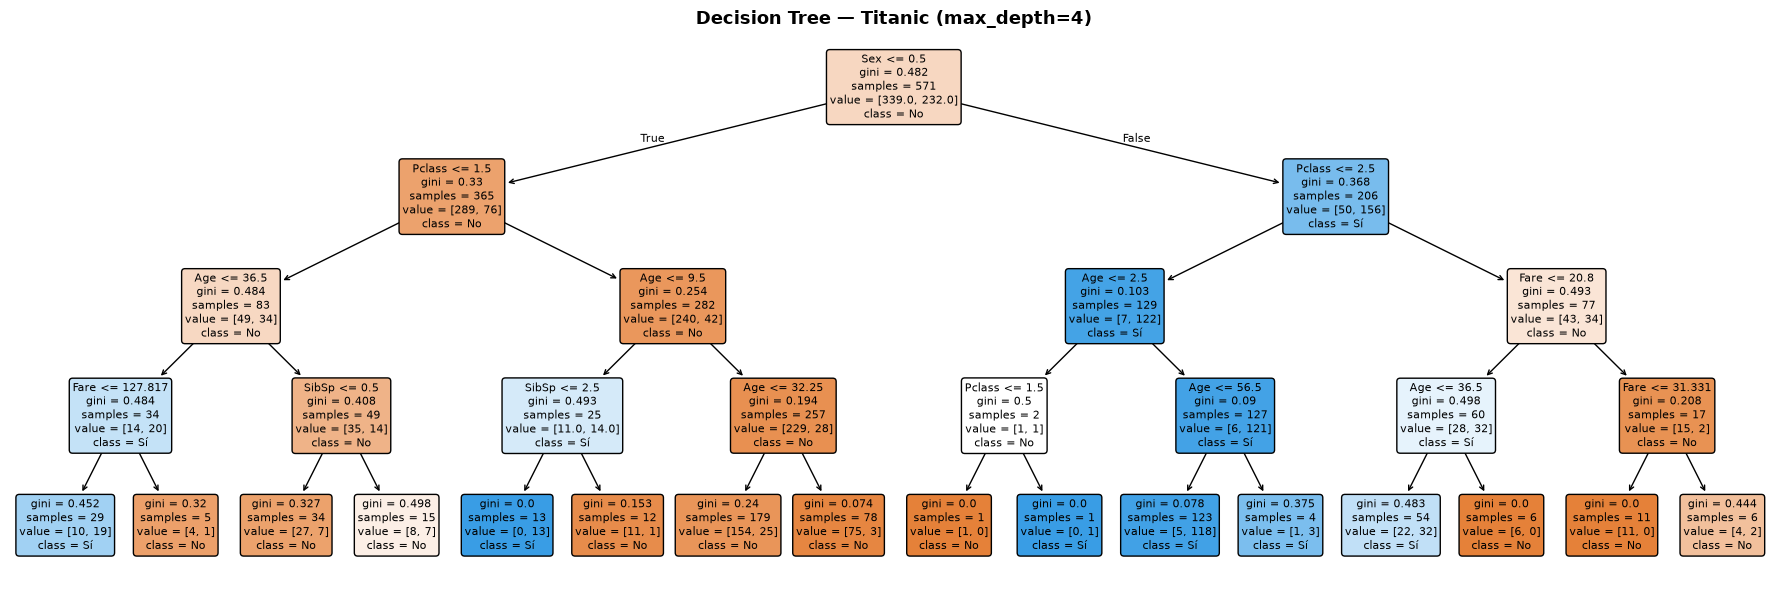

In [11]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

# Árbol regresión
dt_r = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_r.fit(X_hp_tr, y_hp_tr)
pred_dt_r = dt_r.predict(X_hp_te)

mae_dt_r = mean_absolute_error(y_hp_te, pred_dt_r)
r2_dt_r  = r2_score(y_hp_te, pred_dt_r)
print(f'Decision Tree Regresión (max_depth=4)  MAE: {mae_dt_r:.4f}  |  R²: {r2_dt_r:.4f}')

# Árbol clasificación
dt_c = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_c.fit(X_tt_tr, y_tt_tr)
acc_dt_c = accuracy_score(y_tt_te, dt_c.predict(X_tt_te))
print(f'Decision Tree Clasificación (max_depth=4)  Accuracy: {acc_dt_c:.4f}')

# Visualizar el árbol de clasificación
fig, ax = plt.subplots(figsize=(18, 6), facecolor='white')
plot_tree(dt_c, feature_names=X_tt.columns.tolist(),
          class_names=['No','Sí'], filled=True,
          impurity=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree — Titanic (max_depth=4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

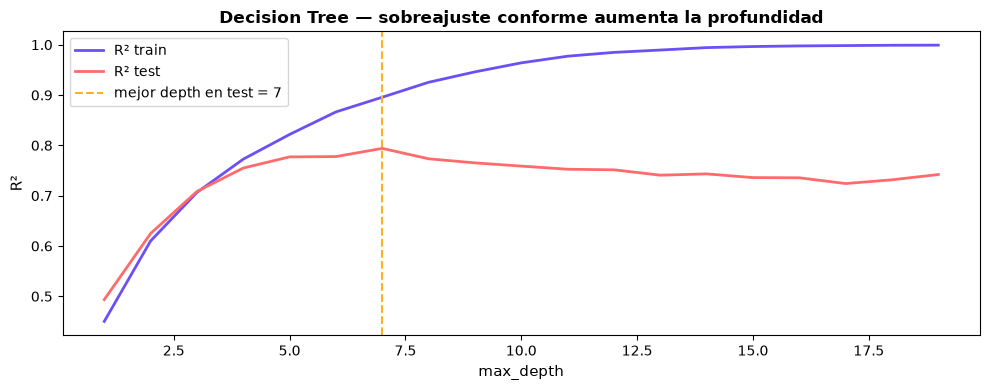

Profundidad óptima (máx R² en test): 7


In [12]:
# Sobreajuste sin max_depth
depths     = range(1, 20)
r2_tr_dt   = []
r2_te_dt   = []

for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_hp_tr, y_hp_tr)
    r2_tr_dt.append(r2_score(y_hp_tr, m.predict(X_hp_tr)))
    r2_te_dt.append(r2_score(y_hp_te, m.predict(X_hp_te)))

best_depth = depths[np.argmax(r2_te_dt)]

fig, ax = plt.subplots(figsize=(10, 4), facecolor='white')
ax.plot(depths, r2_tr_dt, color=VIOLET, linewidth=2, label='R² train')
ax.plot(depths, r2_te_dt, color=CORAL,  linewidth=2, label='R² test')
ax.axvline(best_depth, color=AMBER, linestyle='--', linewidth=1.5,
           label=f'mejor depth en test = {best_depth}')
ax.set_xlabel('max_depth', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('Decision Tree — sobreajuste conforme aumenta la profundidad',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Profundidad óptima (máx R² en test): {best_depth}')

---
## Regularización

Añade una penalización al proceso de entrenamiento para evitar sobreajuste:

| Tipo | Penalización | Efecto |
|------|-------------|--------|
| **L1 (Lasso)** | $\sum abs(\beta_i)$ | Lleva coeficientes aexactamente cero, selección de variables |
| **L2 (Ridge)** | $\sum \beta_i^2$ | Encoge coeficientes hacia cero, todos contribuyen un poco |
| **ElasticNet** | Combinación L1+L2 | Lo mejor de ambos |

> En sklearn: `C` = inverso de la regularización. `C` grande es poca regularización. `C` pequeño es mucha regularización.

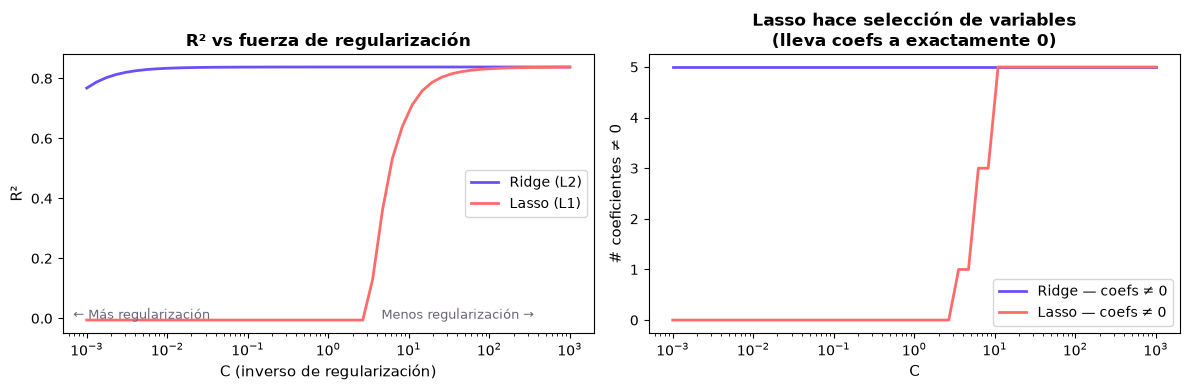

In [13]:
from sklearn.linear_model import Ridge, Lasso

Cs     = np.logspace(-3, 3, 50)
alphas = 1 / Cs

r2_ridge = []
r2_lasso = []
coef_l1  = []
coef_l2  = []

for alpha in alphas:
    ridge = Pipeline([('s', StandardScaler()), ('m', Ridge(alpha=alpha))])
    lasso = Pipeline([('s', StandardScaler()), ('m', Lasso(alpha=alpha, max_iter=5000))])
    ridge.fit(X_hp_tr, y_hp_tr)
    lasso.fit(X_hp_tr, y_hp_tr)
    r2_ridge.append(r2_score(y_hp_te, ridge.predict(X_hp_te)))
    r2_lasso.append(r2_score(y_hp_te, lasso.predict(X_hp_te)))
    coef_l2.append(np.sum(ridge.named_steps['m'].coef_ != 0))
    coef_l1.append(np.sum(lasso.named_steps['m'].coef_ != 0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='white')

axes[0].plot(Cs, r2_ridge, color=VIOLET, linewidth=2, label='Ridge (L2)')
axes[0].plot(Cs, r2_lasso, color=CORAL,  linewidth=2, label='Lasso (L1)')
axes[0].set_xscale('log')
axes[0].set_xlabel('C (inverso de regularización)', fontsize=11)
axes[0].set_ylabel('R²', fontsize=11)
axes[0].set_title('R² vs fuerza de regularización', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].annotate('← Más regularización', xy=(0.02, 0.05),
                 xycoords='axes fraction', fontsize=9, color=MUTED)
axes[0].annotate('Menos regularización →', xy=(0.60, 0.05),
                 xycoords='axes fraction', fontsize=9, color=MUTED)

axes[1].plot(Cs, coef_l2, color=VIOLET, linewidth=2, label='Ridge — coefs ≠ 0')
axes[1].plot(Cs, coef_l1, color=CORAL,  linewidth=2, label='Lasso — coefs ≠ 0')
axes[1].set_xscale('log')
axes[1].set_xlabel('C', fontsize=11)
axes[1].set_ylabel('# coeficientes ≠ 0', fontsize=11)
axes[1].set_title('Lasso hace selección de variables\n(lleva coefs a exactamente 0)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## Random Forest

Entrena muchos árboles sobre subconjuntos aleatorios de datos y features, y promedia sus predicciones:

- **Bagging:** Cada árbol ve una muestra aleatoria con reemplazo (bootstrap)
- **Feature randomness:** Cada split considera solo un subconjunto de features

Los errores de los árboles individuales se cancelan al promediar.

Random Forest Regresión    MAE: 0.1120  |  R²: 0.8455
Random Forest Clasificación  Accuracy: 0.7902



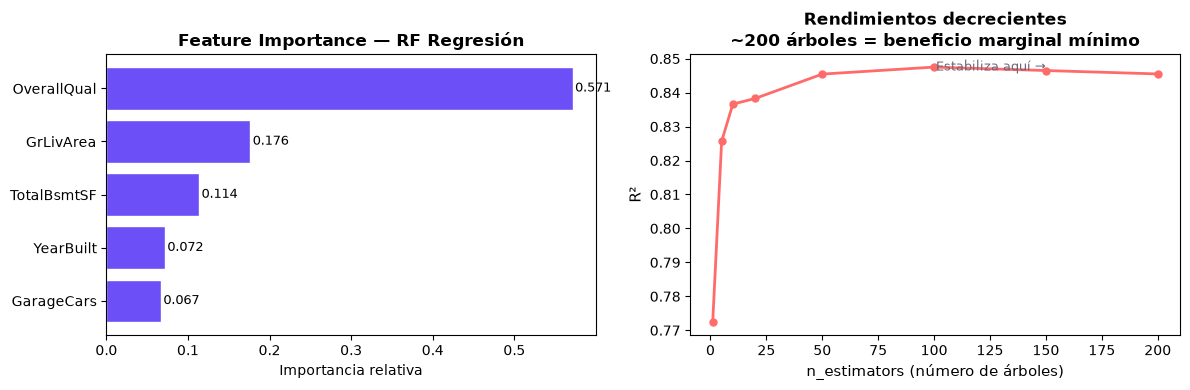

In [14]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# RF Regresión
rf_r = RandomForestRegressor(n_estimators=200, max_depth=None,
                              random_state=42, n_jobs=-1)
rf_r.fit(X_hp_tr, y_hp_tr)
pred_rf_r = rf_r.predict(X_hp_te)

mae_rf_r = mean_absolute_error(y_hp_te, pred_rf_r)
r2_rf_r  = r2_score(y_hp_te, pred_rf_r)
print(f'Random Forest Regresión    MAE: {mae_rf_r:.4f}  |  R²: {r2_rf_r:.4f}')

# RF Clasificación
rf_c = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_c.fit(X_tt_tr, y_tt_tr)
acc_rf_c = accuracy_score(y_tt_te, rf_c.predict(X_tt_te))
print(f'Random Forest Clasificación  Accuracy: {acc_rf_c:.4f}')
print()

# Feature importance
importancias = pd.Series(rf_r.feature_importances_, index=X_hp.columns)\
                 .sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='white')

# Importancia de features
axes[0].barh(importancias.index, importancias.values,
             color=VIOLET, edgecolor='white')
axes[0].set_title('Feature Importance — RF Regresión', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importancia relativa')
for i, v in enumerate(importancias.values):
    axes[0].text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)

# Rendimientos decrecientes
ns       = [1, 5, 10, 20, 50, 100, 150, 200]
r2_ns    = []
for n_est in ns:
    m = RandomForestRegressor(n_estimators=n_est, random_state=42, n_jobs=-1)
    m.fit(X_hp_tr, y_hp_tr)
    r2_ns.append(r2_score(y_hp_te, m.predict(X_hp_te)))

axes[1].plot(ns, r2_ns, color=CORAL, linewidth=2, marker='o', markersize=5)
axes[1].set_xlabel('n_estimators (número de árboles)', fontsize=11)
axes[1].set_ylabel('R²', fontsize=11)
axes[1].set_title('Rendimientos decrecientes\n~200 árboles = beneficio marginal mínimo',
                  fontsize=12, fontweight='bold')
axes[1].annotate('Estabiliza aquí →', xy=(150, r2_ns[-2]),
                 fontsize=9, color=MUTED, ha='right')

plt.tight_layout()
plt.show()

---
## XGBoost

A diferencia de Random Forest (árboles en paralelo), XGBoost los entrena en secuencia. Cada árbol corrige los errores del anterior, eso se llama boosting.

| | Random Forest | XGBoost |
|-|--------------|----------|
| Estrategia | Bagging (paralelo) | Boosting (secuencial) |
| Cada árbol ve | Bootstrap del dataset | Residuos del árbol anterior |
| Tuning necesario | Poco | Más cuidado |
| Overfitting | Más robusto | Más susceptible |

> `learning_rate` y `n_estimators` van de la mano: Learning rate bajo hace que necesites más árboles.

XGBoost Regresión    MAE: 0.1103  |  R²: 0.8584
XGBoost Clasificación  Accuracy: 0.7832



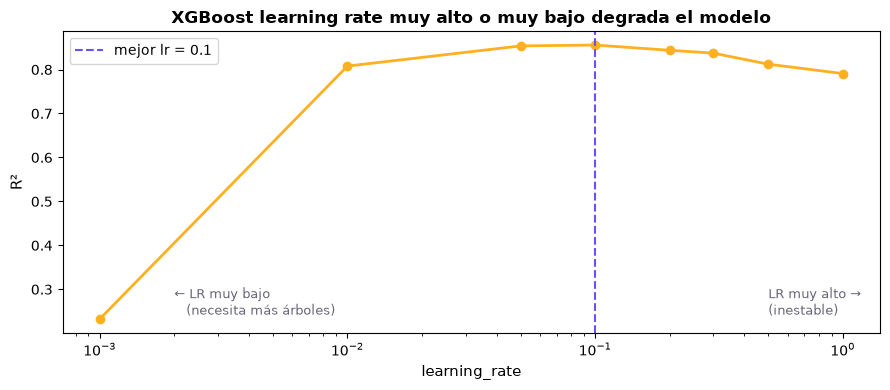

In [15]:
from xgboost import XGBRegressor, XGBClassifier

# XGB Regresión
xgb_r = XGBRegressor(n_estimators=200, learning_rate=0.1,
                     max_depth=4, subsample=0.8,
                     colsample_bytree=0.8, random_state=42,
                     verbosity=0)
xgb_r.fit(X_hp_tr, y_hp_tr)
pred_xgb_r = xgb_r.predict(X_hp_te)

mae_xgb_r = mean_absolute_error(y_hp_te, pred_xgb_r)
r2_xgb_r  = r2_score(y_hp_te, pred_xgb_r)
print(f'XGBoost Regresión    MAE: {mae_xgb_r:.4f}  |  R²: {r2_xgb_r:.4f}')

# XGB Clasificación
xgb_c = XGBClassifier(n_estimators=200, learning_rate=0.1,
                      max_depth=4, subsample=0.8,
                      colsample_bytree=0.8, random_state=42,
                      verbosity=0, eval_metric='logloss')
xgb_c.fit(X_tt_tr, y_tt_tr)
acc_xgb_c = accuracy_score(y_tt_te, xgb_c.predict(X_tt_te))
print(f'XGBoost Clasificación  Accuracy: {acc_xgb_c:.4f}')
print()

# Efecto del learning rate
lrs    = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
r2_lr_xgb  = []
for lr in lrs:
    m = XGBRegressor(n_estimators=200, learning_rate=lr,
                     max_depth=4, random_state=42, verbosity=0)
    m.fit(X_hp_tr, y_hp_tr)
    r2_lr_xgb.append(r2_score(y_hp_te, m.predict(X_hp_te)))

fig, ax = plt.subplots(figsize=(9, 4), facecolor='white')
ax.plot(lrs, r2_lr_xgb, color=AMBER, linewidth=2, marker='o', markersize=6)
ax.set_xscale('log')
ax.set_xlabel('learning_rate', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('XGBoost learning rate muy alto o muy bajo degrada el modelo',
             fontsize=12, fontweight='bold')
best_lr = lrs[np.argmax(r2_lr_xgb)]
ax.axvline(best_lr, color=VIOLET, linestyle='--', linewidth=1.5,
           label=f'mejor lr = {best_lr}')
ax.legend(fontsize=10)
ax.annotate('← LR muy bajo\n   (necesita más árboles)', xy=(0.002, min(r2_lr_xgb)+0.01),
             fontsize=9, color=MUTED)
ax.annotate('LR muy alto →\n(inestable)', xy=(0.5, min(r2_lr_xgb)+0.01),
             fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()

---
## Comparativa final — todos los modelos

La API de sklearn es consistente, cambiar de modelo es cambiar una línea:

```python
modelo = LinearRegression()      # ← solo cambias esto
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
```

In [16]:
# Resumen regresión
reg_resultados = pd.DataFrame({
    'Modelo': ['Baseline (media)', 'Regresión Lineal', f'KNN (K={k_inicial})',
               'Decision Tree (d=4)', 'Random Forest', 'XGBoost'],
    'MAE':   [mae_base, mae_lr, mae_knn_r, mae_dt_r, mae_rf_r, mae_xgb_r],
    'R²':    [r2_base,  r2_lr,  r2_knn_r,  r2_dt_r,  r2_rf_r,  r2_xgb_r]
}).sort_values('R²', ascending=False)

print('=== REGRESIÓN — House Prices ===')
print(reg_resultados.to_string(index=False, float_format='{:.4f}'.format))

# Resumen clasificación
clf_resultados = pd.DataFrame({
    'Modelo': ['Baseline (mayoría)', 'Reg. Logística', f'KNN (K={k_inicial_clf})',
               'Decision Tree (d=4)', 'Random Forest', 'XGBoost'],
    'Accuracy': [acc_base, accuracy, acc_knn_c, acc_dt_c, acc_rf_c, acc_xgb_c]
}).sort_values('Accuracy', ascending=False)

print('\n=== CLASIFICACIÓN — Titanic ===')
print(clf_resultados.to_string(index=False, float_format='{:.4f}'.format))

=== REGRESIÓN — House Prices ===
             Modelo    MAE      R²
            XGBoost 0.1103  0.8584
      Random Forest 0.1120  0.8455
   Regresión Lineal 0.1213  0.8380
         KNN (K=34) 0.1245  0.8134
Decision Tree (d=4) 0.1569  0.7549
   Baseline (media) 0.3371 -0.0058

=== CLASIFICACIÓN — Titanic ===
             Modelo  Accuracy
         KNN (K=23)    0.8322
Decision Tree (d=4)    0.8042
     Reg. Logística    0.7972
      Random Forest    0.7902
            XGBoost    0.7832
 Baseline (mayoría)    0.5944


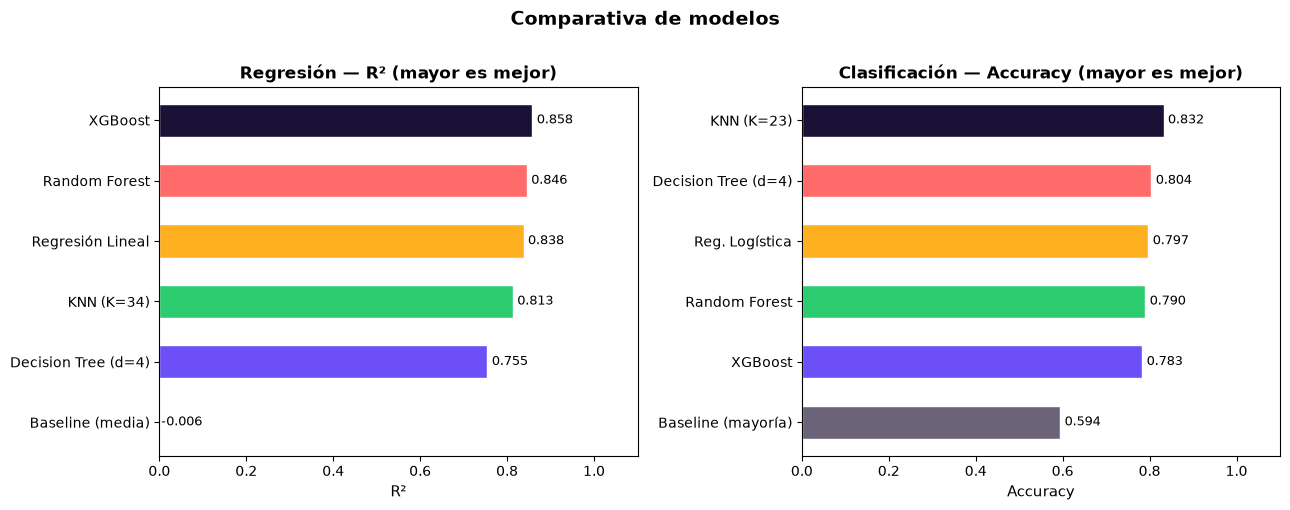

In [17]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

colores_modelos = [MUTED, VIOLET, GREEN, AMBER, CORAL, DARK]

# Regresión
reg_plot = reg_resultados.sort_values('R²')
bars = axes[0].barh(reg_plot['Modelo'], reg_plot['R²'],
                    color=colores_modelos, edgecolor='white', height=0.55)
axes[0].set_xlabel('R²', fontsize=11)
axes[0].set_title('Regresión — R² (mayor es mejor)', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 1.1)
for bar, val in zip(bars, reg_plot['R²']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# Clasificación
clf_plot = clf_resultados.sort_values('Accuracy')
bars2 = axes[1].barh(clf_plot['Modelo'], clf_plot['Accuracy'],
                     color=colores_modelos, edgecolor='white', height=0.55)
axes[1].set_xlabel('Accuracy', fontsize=11)
axes[1].set_title('Clasificación — Accuracy (mayor es mejor)', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 1.1)
for bar, val in zip(bars2, clf_plot['Accuracy']):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

fig.suptitle('Comparativa de modelos', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()